# Clustering jerárquico sobre embeddings reducidos con autoencoder

Réplica del análisis de `hc_clustering.ipynb`, pero en lugar de usar los embeddings
originales, cada representación se **reduce de dimensión con un autoencoder** y el
**espacio latente** se usa como embedding para el clustering jerárquico (Ward).

| Técnica | Entrada al autoencoder |
|---|---|
| TF-IDF | TruncatedSVD a 50 componentes (LSA), L2-normalizado |
| MiniLM multilingüe | vectores densos de 384 dims, L2-normalizados |
| BGE-M3 (vLLM) | vectores densos de 1024 dims, L2-normalizados |

**Selección del autoencoder:** para cada técnica se entrena una grilla de configuraciones
(arquitectura del encoder × dimensión latente) y se elige la de **menor error de
reconstrucción (MSE) en un conjunto de validación** (15% de la muestra). Nota: a mayor
dimensión latente el error de reconstrucción tiende a bajar, por lo que este criterio
favorece los latentes más grandes de la grilla; se sigue igualmente por ser el criterio
definido para el experimento.

El resto del análisis es idéntico al de `hc_clustering.ipynb`: linkage de Ward,
correlación cofenética, silhouette / Calinski-Harabasz / Davies-Bouldin para k = 2…15,
dendrogramas, t-SNE y titulación de clústeres con DeepSeek vía vLLM.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch import nn

sys.path.insert(0, str(Path.cwd().parent))

PALETA = ["#2a78d6", "#008300", "#e87ba4"]
sns.set_theme(style="whitegrid", palette=PALETA)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.color": "#e1e0d9",
                     "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e"})
RANDOM_STATE = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__} — dispositivo: {DEVICE}")


PyTorch 2.13.0+cpu — dispositivo: cpu


## Reproducción de la submuestra del EDA

Se replica exactamente la submuestra estratificada de ~1,500 artículos del EDA
(misma limpieza, mismos estratos año × periódico, mismo `random_state`) y se verifica
contra los `id_articulo` guardados en `data/embeddings/muestra_ids.npy` para garantizar
que los embeddings cacheados corresponden a estos textos.


In [2]:
import re
from math import ceil

data = pd.read_csv("../data/raw/stratified_sample_2019_2026.csv")
data.drop(columns=["anio", "id_pressreader", "id_periodico", "icor_index", "icor_v2_index"], inplace=True)
data["fecha"] = pd.to_datetime(data["fecha"])
data["anio"] = data["fecha"].dt.year


def norm_text(text: str) -> str:
    """Normaliza un texto: minúsculas y colapso de espacios en blanco."""
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()


data["texto_norm"] = data["texto"].map(norm_text)

N_MUESTRA = 1500
estratos = data.groupby(["nombre_periodico", "anio"])
cuota = ceil(N_MUESTRA / estratos.ngroups)
muestra = pd.concat(
    [g.sample(min(len(g), cuota), random_state=RANDOM_STATE) for _, g in estratos]
).sort_values(["anio", "nombre_periodico", "id_articulo"]).reset_index(drop=True)

textos_emb = (muestra["titulo"].fillna("").map(norm_text) + ". "
              + muestra["texto_norm"]).str.slice(0, 2000).tolist()

EMB_DIR = Path("../data/embeddings")
ids_muestra = muestra["id_articulo"].to_numpy()
assert np.array_equal(np.load(EMB_DIR / "muestra_ids.npy"), ids_muestra), \
    "La submuestra no coincide con la usada en el EDA: recalcular embeddings en eda.ipynb"
print(f"Submuestra reproducida: {len(muestra)} artículos — ids verificados contra el caché")


Submuestra reproducida: 1512 artículos — ids verificados contra el caché


## Carga de embeddings originales (entradas del autoencoder)

MiniLM y BGE-M3 se cargan del caché generado por `eda.ipynb`; TF-IDF se recalcula con
los mismos hiperparámetros y se reduce con `TruncatedSVD` a 50 componentes, igual que en
`hc_clustering.ipynb`. Todos se L2-normalizan: estos vectores son la **entrada** que el
autoencoder aprende a reconstruir.


In [3]:
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

vectorizador = TfidfVectorizer(max_features=50_000, min_df=3, max_df=0.6, sublinear_tf=True)
emb_tfidf_sparse = vectorizador.fit_transform(textos_emb)
emb_tfidf = TruncatedSVD(n_components=50, random_state=RANDOM_STATE).fit_transform(emb_tfidf_sparse)

emb_st = np.load(EMB_DIR / "minilm_multilingual.npy")
emb_bge = np.load(EMB_DIR / "bge_m3.npy")

embeddings = {
    "TF-IDF (SVD-50)": normalize(emb_tfidf),
    "MiniLM multilingüe": normalize(emb_st),
    "BGE-M3": normalize(emb_bge),
}
for nombre, emb in embeddings.items():
    print(f"{nombre}: {emb.shape}")


TF-IDF (SVD-50): (1512, 50)
MiniLM multilingüe: (1512, 384)
BGE-M3: (1512, 1024)


## Autoencoder: arquitectura y búsqueda de configuraciones

Autoencoder MLP **simétrico** (decoder espejo del encoder) con activaciones ReLU,
entrenado para minimizar el MSE de reconstrucción con Adam y *early stopping* sobre un
conjunto de validación (15% de la muestra, partición fija con `RANDOM_STATE`).

Grilla de pruebas por técnica:

- **Dimensión latente:** 16, 32, 64 (se omiten latentes ≥ dimensión de entrada).
- **Capas ocultas del encoder:** ninguna (`entrada → latente`), una (`entrada → 128 → latente`)
  y dos (`entrada → 256 → 128 → latente`).

Para cada técnica se conserva el autoencoder con **menor MSE de validación** y su espacio
latente reemplaza al embedding original en el resto del análisis.


In [4]:
class Autoencoder(nn.Module):
    """Autoencoder MLP simétrico: decoder espejo del encoder, activaciones ReLU."""

    def __init__(self, dim_entrada: int, dims_ocultas: list[int], dim_latente: int):
        super().__init__()
        dims_enc = [dim_entrada, *dims_ocultas]
        capas_enc = []
        for d_in, d_out in zip(dims_enc, dims_enc[1:]):
            capas_enc += [nn.Linear(d_in, d_out), nn.ReLU()]
        capas_enc.append(nn.Linear(dims_enc[-1], dim_latente))
        self.encoder = nn.Sequential(*capas_enc)

        dims_dec = [dim_latente, *reversed(dims_ocultas)]
        capas_dec = []
        for d_in, d_out in zip(dims_dec, dims_dec[1:]):
            capas_dec += [nn.Linear(d_in, d_out), nn.ReLU()]
        capas_dec.append(nn.Linear(dims_dec[-1], dim_entrada))
        self.decoder = nn.Sequential(*capas_dec)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.encoder(x))


def entrenar_autoencoder(X: np.ndarray, dims_ocultas: list[int], dim_latente: int,
                         epocas: int = 500, paciencia: int = 40,
                         lr: float = 1e-3, batch: int = 128):
    """Entrena un autoencoder y devuelve (modelo, mse_validacion).

    Partición fija 85/15 train/validación; early stopping por MSE de validación,
    restaurando los pesos del mejor punto.
    """
    torch.manual_seed(RANDOM_STATE)
    rng = np.random.default_rng(RANDOM_STATE)
    orden = rng.permutation(len(X))
    n_val = int(len(X) * 0.15)
    X_val = torch.tensor(X[orden[:n_val]], dtype=torch.float32, device=DEVICE)
    X_tr = torch.tensor(X[orden[n_val:]], dtype=torch.float32, device=DEVICE)

    modelo = Autoencoder(X.shape[1], dims_ocultas, dim_latente).to(DEVICE)
    optimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    perdida = nn.MSELoss()

    mejor_val, mejor_estado, sin_mejora = float("inf"), None, 0
    for _ in range(epocas):
        modelo.train()
        barajado = torch.randperm(len(X_tr), device=DEVICE)
        for i in range(0, len(X_tr), batch):
            lote = X_tr[barajado[i:i + batch]]
            optimizador.zero_grad()
            error = perdida(modelo(lote), lote)
            error.backward()
            optimizador.step()
        modelo.eval()
        with torch.no_grad():
            mse_val = perdida(modelo(X_val), X_val).item()
        if mse_val < mejor_val - 1e-7:
            mejor_val, sin_mejora = mse_val, 0
            mejor_estado = {k: v.clone() for k, v in modelo.state_dict().items()}
        else:
            sin_mejora += 1
            if sin_mejora >= paciencia:
                break
    modelo.load_state_dict(mejor_estado)
    modelo.eval()
    return modelo, mejor_val


In [5]:
DIMS_LATENTES = [16, 32, 64]
ARQUITECTURAS = {
    "sin ocultas": [],
    "1 oculta (128)": [128],
    "2 ocultas (256→128)": [256, 128],
}

filas, modelos_ae = [], {}
for nombre, emb in embeddings.items():
    for etiqueta_arq, dims_ocultas in ARQUITECTURAS.items():
        for dim_latente in DIMS_LATENTES:
            if dim_latente >= emb.shape[1]:
                continue
            modelo, mse_val = entrenar_autoencoder(emb, dims_ocultas, dim_latente)
            modelos_ae[(nombre, etiqueta_arq, dim_latente)] = modelo
            filas.append({"tecnica": nombre, "arquitectura": etiqueta_arq,
                          "dim_latente": dim_latente, "mse_val": mse_val})
            print(f"{nombre} | {etiqueta_arq} | latente={dim_latente}: "
                  f"MSE val = {mse_val:.6f}")

pruebas_ae = pd.DataFrame(filas)


TF-IDF (SVD-50) | sin ocultas | latente=16: MSE val = 0.009080


TF-IDF (SVD-50) | sin ocultas | latente=32: MSE val = 0.004992


TF-IDF (SVD-50) | 1 oculta (128) | latente=16: MSE val = 0.006266


TF-IDF (SVD-50) | 1 oculta (128) | latente=32: MSE val = 0.002609


TF-IDF (SVD-50) | 2 ocultas (256→128) | latente=16: MSE val = 0.006144


...

BGE-M3 | 1 oculta (128) | latente=32: MSE val = 0.000445


BGE-M3 | 1 oculta (128) | latente=64: MSE val = 0.000397


BGE-M3 | 2 ocultas (256→128) | latente=16: MSE val = 0.000498


BGE-M3 | 2 ocultas (256→128) | latente=32: MSE val = 0.000458


BGE-M3 | 2 ocultas (256→128) | latente=64: MSE val = 0.000433


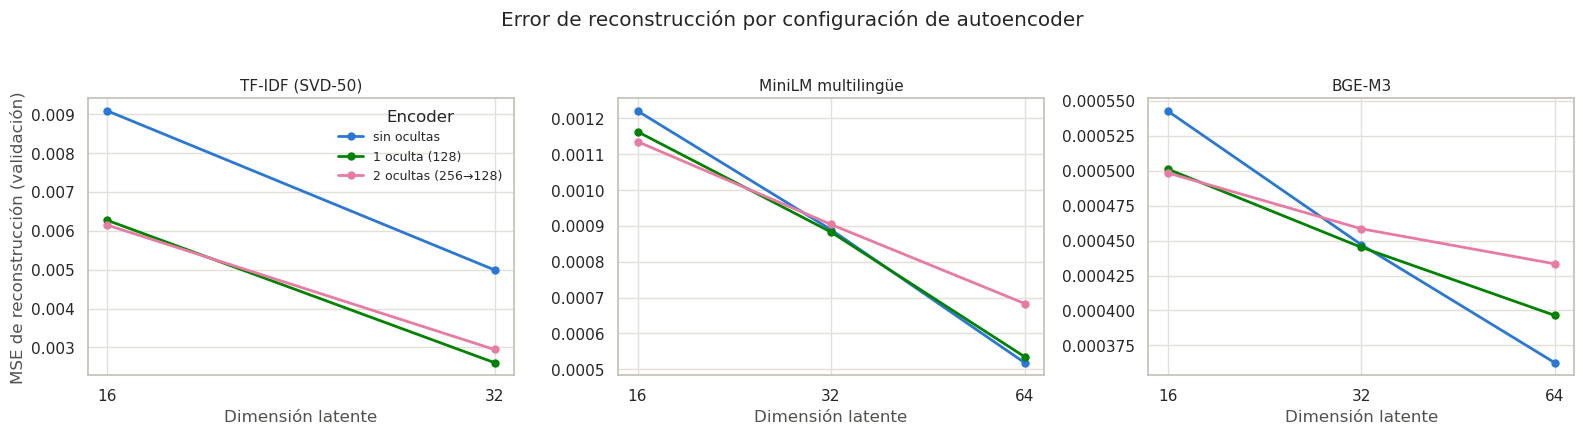

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharey=False)
for ax, nombre in zip(axes, embeddings):
    sub = pruebas_ae[pruebas_ae["tecnica"] == nombre]
    for color, (etiqueta_arq, g) in zip(PALETA, sub.groupby("arquitectura", sort=False)):
        ax.plot(g["dim_latente"], g["mse_val"], marker="o", markersize=5,
                linewidth=2, color=color, label=etiqueta_arq)
    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel("Dimensión latente")
    ax.set_xscale("log", base=2)
    ax.set_xticks(sorted(sub["dim_latente"].unique()))
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
axes[0].set_ylabel("MSE de reconstrucción (validación)")
axes[0].legend(frameon=False, fontsize=9, title="Encoder")
plt.suptitle("Error de reconstrucción por configuración de autoencoder", y=1.03)
plt.tight_layout()
plt.show()


## Selección del mejor autoencoder y proyección al espacio latente

Se toma, por técnica, la configuración con menor MSE de validación; el encoder de ese
modelo proyecta **toda** la muestra al espacio latente y el resultado se L2-normaliza
(igual que los embeddings originales) para que Ward opere sobre distancias comparables
a coseno.


In [7]:
mejores_ae = (pruebas_ae.loc[pruebas_ae.groupby("tecnica", sort=False)["mse_val"].idxmin()]
              .set_index("tecnica"))
display(mejores_ae.round(6))

embeddings_lat = {}
for nombre, fila in mejores_ae.iterrows():
    modelo = modelos_ae[(nombre, fila["arquitectura"], fila["dim_latente"])]
    with torch.no_grad():
        latente = modelo.encoder(
            torch.tensor(embeddings[nombre], dtype=torch.float32, device=DEVICE)
        ).cpu().numpy()
    embeddings_lat[nombre] = normalize(latente)
    print(f"{nombre}: {embeddings[nombre].shape[1]} dims → latente {latente.shape[1]} "
          f"({fila['arquitectura']}, MSE val {fila['mse_val']:.6f})")


,arquitectura,dim_latente,mse_val
tecnica,,,
TF-IDF (SVD-50),1 oculta (128),32,0.002609
MiniLM multilingüe,sin ocultas,64,0.000518
BGE-M3,sin ocultas,64,0.000363


TF-IDF (SVD-50): 50 dims → latente 32 (1 oculta (128), MSE val 0.002609)
MiniLM multilingüe: 384 dims → latente 64 (sin ocultas, MSE val 0.000518)
BGE-M3: 1024 dims → latente 64 (sin ocultas, MSE val 0.000363)


## Linkage jerárquico (Ward) y dendrogramas sobre el espacio latente

Se construye la jerarquía completa con `scipy.cluster.hierarchy.linkage(method="ward")`
sobre los embeddings latentes y se reporta la **correlación cofenética** de cada árbol.
Los dendrogramas se truncan a los últimos 30 merges para legibilidad.


In [8]:
from scipy.cluster.hierarchy import cophenet, dendrogram, fcluster, linkage
from scipy.spatial.distance import pdist

linkages, cofeneticas = {}, {}
for nombre, emb in embeddings_lat.items():
    dist = pdist(emb)
    Z = linkage(emb, method="ward")
    linkages[nombre] = Z
    cofeneticas[nombre], _ = cophenet(Z, dist)
    print(f"{nombre}: correlación cofenética = {cofeneticas[nombre]:.3f}")


TF-IDF (SVD-50): correlación cofenética = 0.453


MiniLM multilingüe: correlación cofenética = 0.300


BGE-M3: correlación cofenética = 0.307

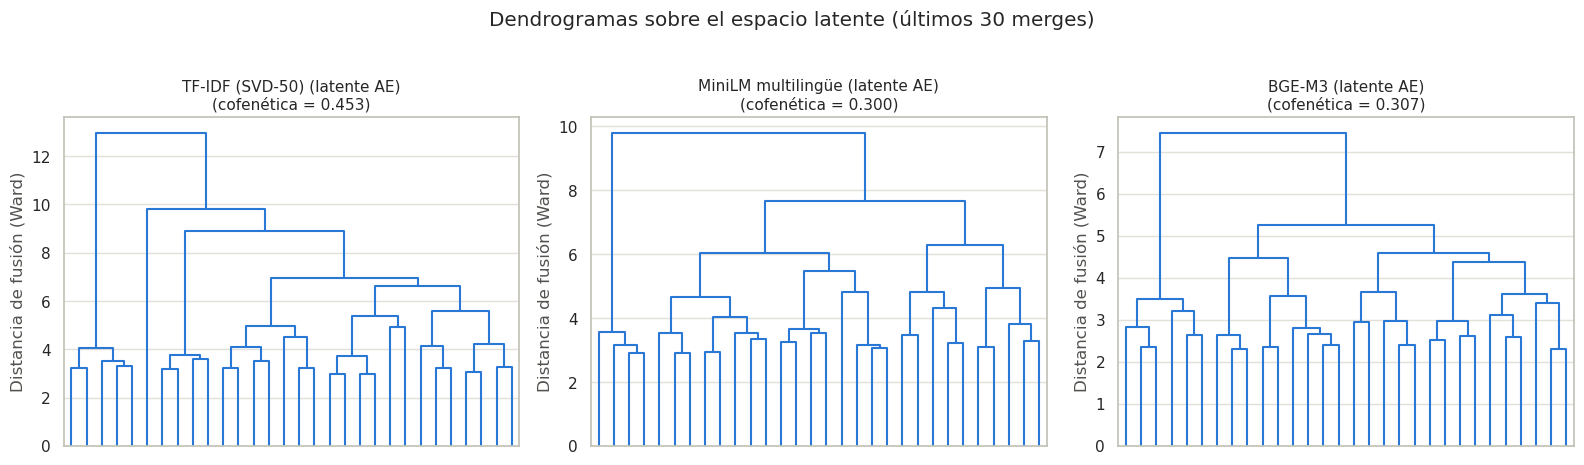

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (nombre, Z) in zip(axes, linkages.items()):
    dendrogram(Z, truncate_mode="lastp", p=30, ax=ax, no_labels=True,
               color_threshold=0, above_threshold_color="#2a78d6")
    ax.set_title(f"{nombre} (latente AE)\n(cofenética = {cofeneticas[nombre]:.3f})", fontsize=11)
    ax.set_ylabel("Distancia de fusión (Ward)")
    ax.set_xticks([])
plt.suptitle("Dendrogramas sobre el espacio latente (últimos 30 merges)", y=1.03)
plt.tight_layout()
plt.show()


## Métricas no supervisadas por número de clústeres

Para cada técnica se corta el dendrograma en k = 2…15 y se calculan silhouette
(con distancia coseno), Calinski-Harabasz y Davies-Bouldin, todo sobre el espacio latente.


In [10]:
from sklearn.metrics import (calinski_harabasz_score, davies_bouldin_score,
                             silhouette_score)

RANGO_K = range(2, 16)
filas = []
etiquetas_por_k = {}
for nombre, emb in embeddings_lat.items():
    Z = linkages[nombre]
    for k in RANGO_K:
        etiquetas = fcluster(Z, t=k, criterion="maxclust")
        etiquetas_por_k[(nombre, k)] = etiquetas
        filas.append({
            "tecnica": nombre,
            "k": k,
            "silhouette": silhouette_score(emb, etiquetas, metric="cosine"),
            "calinski_harabasz": calinski_harabasz_score(emb, etiquetas),
            "davies_bouldin": davies_bouldin_score(emb, etiquetas),
        })

metricas = pd.DataFrame(filas)
metricas.head()


,tecnica,k,silhouette,calinski_harabasz,davies_bouldin
0,TF-IDF (SVD-50),2,0.160020,142.183518,2.318821
1,TF-IDF (SVD-50),3,0.160294,118.196869,2.000231
2,TF-IDF (SVD-50),4,0.151803,107.456913,2.372589
3,TF-IDF (SVD-50),5,0.140914,94.745692,3.175933
4,TF-IDF (SVD-50),6,0.145387,86.631578,3.104890


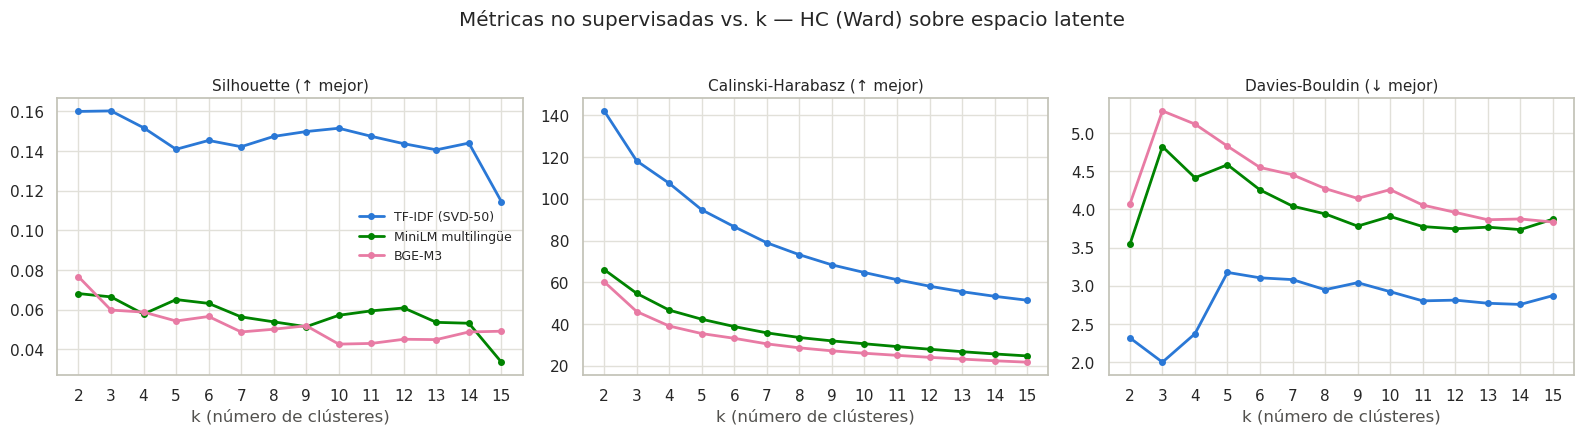

In [11]:
COLORES_TEC = dict(zip(embeddings_lat, PALETA))
config_metricas = [("silhouette", "Silhouette (↑ mejor)"),
                   ("calinski_harabasz", "Calinski-Harabasz (↑ mejor)"),
                   ("davies_bouldin", "Davies-Bouldin (↓ mejor)")]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, (col, titulo) in zip(axes, config_metricas):
    for nombre in embeddings_lat:
        serie = metricas[metricas["tecnica"] == nombre]
        ax.plot(serie["k"], serie[col], marker="o", markersize=4, linewidth=2,
                color=COLORES_TEC[nombre], label=nombre)
    ax.set_xlabel("k (número de clústeres)")
    ax.set_title(titulo, fontsize=11)
    ax.set_xticks(list(RANGO_K))
axes[0].legend(frameon=False, fontsize=9)
plt.suptitle("Métricas no supervisadas vs. k — HC (Ward) sobre espacio latente", y=1.03)
plt.tight_layout()
plt.show()


## Resumen: mejor k por técnica

Se elige el k que maximiza silhouette y se reportan las tres métricas en ese corte,
junto con el tamaño de los clústeres resultantes.


In [12]:
mejores = (metricas.loc[metricas.groupby("tecnica")["silhouette"].idxmax()]
           .set_index("tecnica").round(3))
mejores["cofenetica"] = pd.Series(cofeneticas).round(3)
mejores


,k,silhouette,calinski_harabasz,davies_bouldin,cofenetica
tecnica,,,,,
BGE-M3,2,0.077,60.243,4.070,0.307
MiniLM multilingüe,2,0.068,66.093,3.543,0.300
TF-IDF (SVD-50),3,0.160,118.197,2.000,0.453


In [13]:
for nombre in embeddings_lat:
    k = int(mejores.loc[nombre, "k"])
    tam = np.bincount(etiquetas_por_k[(nombre, k)])[1:].tolist()
    print(f"{nombre} (k={k}): tamaños de clúster = {sorted(tam, reverse=True)}")


TF-IDF (SVD-50) (k=3): tamaños de clúster = [1167, 270, 75]
MiniLM multilingüe (k=2): tamaños de clúster = [1236, 276]
BGE-M3 (k=2): tamaños de clúster = [1180, 332]


## Árboles completos coloreados por el corte óptimo

Dendrograma **completo** (todas las hojas) de cada técnica sobre el espacio latente.
La línea punteada marca la altura de corte que produce el mejor k según silhouette;
las ramas por debajo de esa altura se colorean por clúster resultante.


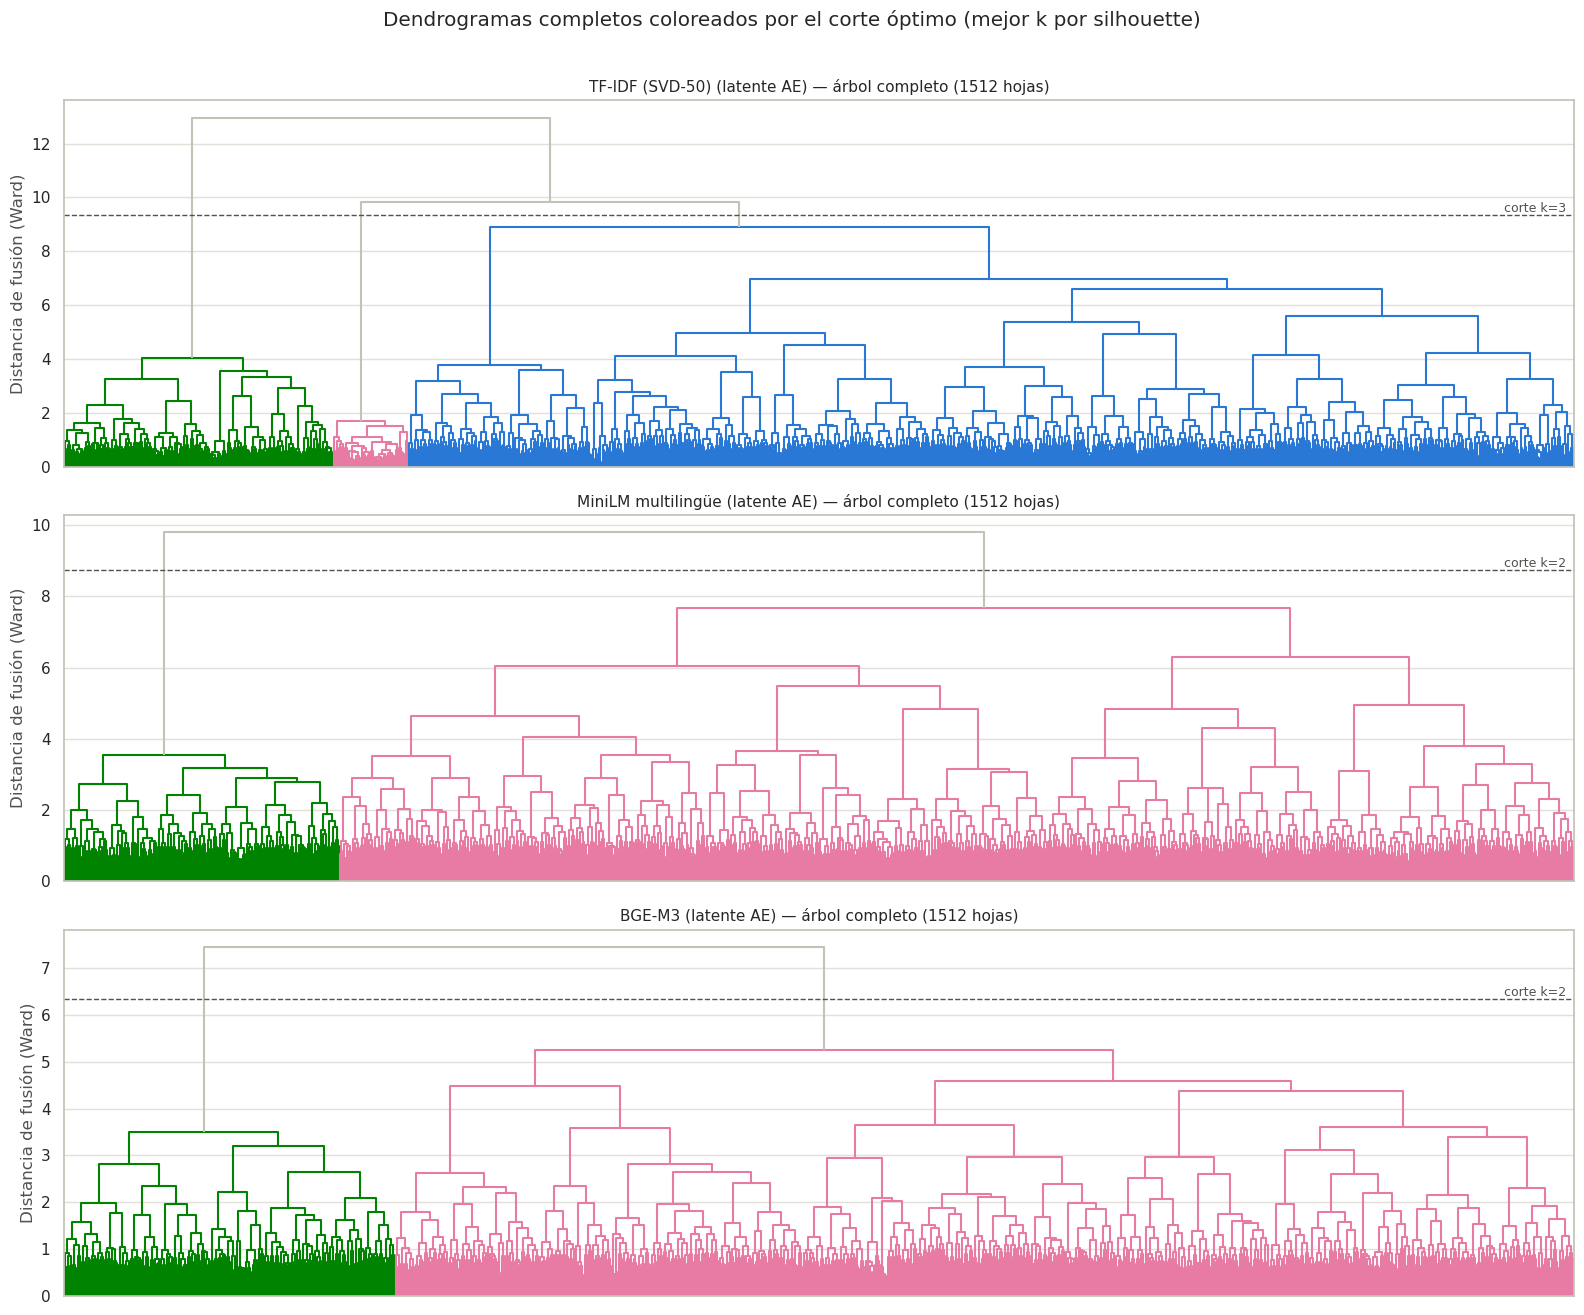

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(16, 13))
for ax, (nombre, Z) in zip(axes, linkages.items()):
    k = int(mejores.loc[nombre, "k"])
    # Altura de corte: punto medio entre los merges que dejan k y k-1 clústeres
    umbral = (Z[-k, 2] + Z[-(k - 1), 2]) / 2 if k > 1 else Z[-1, 2] * 1.05
    dendrogram(Z, ax=ax, no_labels=True, color_threshold=umbral,
               above_threshold_color="#c3c2b7")
    ax.axhline(umbral, color="#52514e", linestyle="--", linewidth=1)
    ax.text(0.995, umbral, f" corte k={k}", transform=ax.get_yaxis_transform(),
            ha="right", va="bottom", fontsize=9, color="#52514e")
    ax.set_title(f"{nombre} (latente AE) — árbol completo ({Z.shape[0] + 1} hojas)", fontsize=11)
    ax.set_ylabel("Distancia de fusión (Ward)")
    ax.set_xticks([])
plt.suptitle("Dendrogramas completos coloreados por el corte óptimo (mejor k por silhouette)", y=1.01)
plt.tight_layout()
plt.show()


## Visualización de los cortes óptimos (t-SNE)

Proyección t-SNE 2D de cada espacio latente (los latentes ya tienen ≤ 64 dims, así que
no se aplica reducción previa) coloreada por el clúster jerárquico en el mejor k.


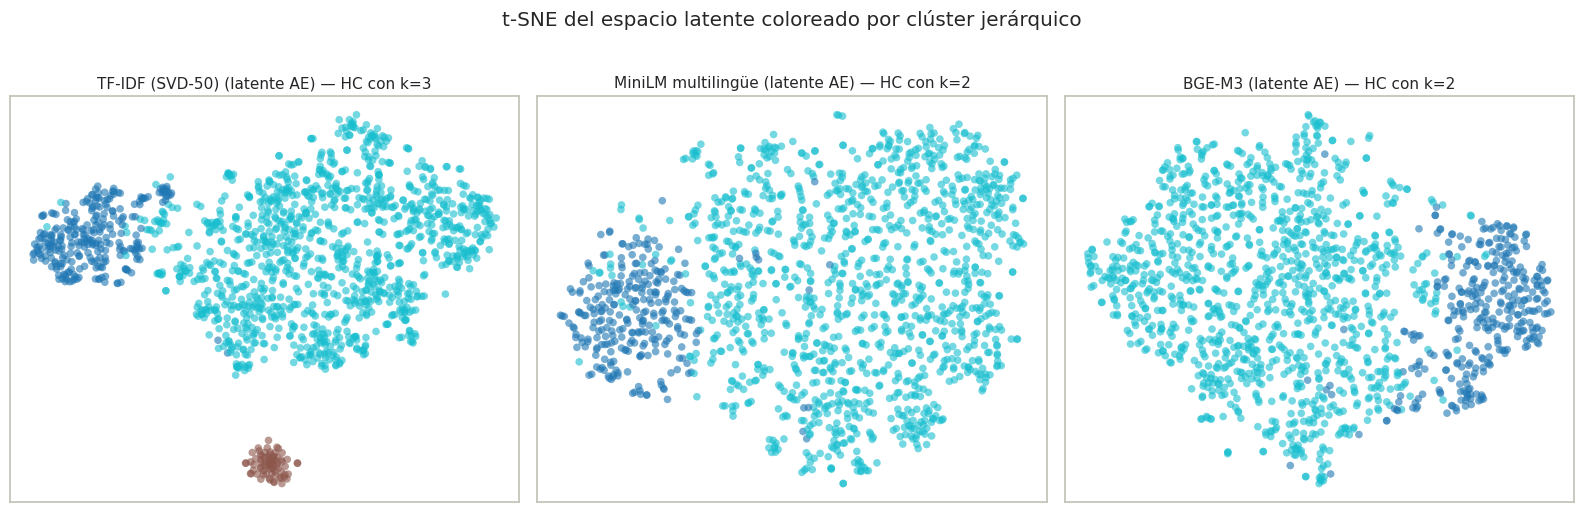

In [15]:
from sklearn.manifold import TSNE

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (nombre, emb) in zip(axes, embeddings_lat.items()):
    xy = TSNE(n_components=2, init="pca", perplexity=30, max_iter=1000,
              random_state=RANDOM_STATE).fit_transform(emb)
    k = int(mejores.loc[nombre, "k"])
    etiquetas = etiquetas_por_k[(nombre, k)]
    ax.scatter(xy[:, 0], xy[:, 1], c=etiquetas, cmap="tab10", s=30, alpha=0.6, linewidths=0)
    ax.set_title(f"{nombre} (latente AE) — HC con k={k}", fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("t-SNE del espacio latente coloreado por clúster jerárquico", y=1.02)
plt.tight_layout()
plt.show()


## Títulos descriptivos por clúster (DeepSeek vía vLLM)

Para cada clúster del corte óptimo se toma una **muestra aleatoria de 10 artículos**
(título + inicio del texto) y se pide a `deepseek-ai/DeepSeek-V4-Flash` (servidor H200,
cliente de `src/llm_clients`) un **título descriptivo corto** del tema dominante.
**Requiere VPN GlobalProtect activa.**

Nota: DeepSeek es un modelo de razonamiento — consume parte del presupuesto de
`max_tokens` en el campo `reasoning` antes de emitir `content`, por eso se usa un
límite generoso aunque la respuesta esperada sea corta.


In [16]:
from src.llm_clients import get_chat_client, load_config

config = load_config()
cliente_chat = get_chat_client(config)
N_EJEMPLOS = 10

PROMPT_TITULO = (
    "Eres un analista de prensa ecuatoriana. A continuación tienes una muestra de "
    "artículos (título y primeras líneas) que pertenecen a un mismo clúster temático "
    "obtenido por clustering no supervisado.\n\n{ejemplos}\n\n"
    "Escribe UN solo título descriptivo en español (máximo 10 palabras) que resuma el "
    "tema dominante del clúster. Si los temas son heterogéneos, dilo en el título "
    "(p. ej. 'Actualidad general: política, deportes y sucesos'). "
    "Responde únicamente con el título, sin comillas ni explicaciones."
)


def titular_cluster(indices: np.ndarray) -> str:
    """Pide a DeepSeek un título descriptivo para los artículos indicados."""
    ejemplos = "\n".join(
        f"- {muestra.loc[i, 'titulo'] or '(sin título)'}: "
        f"{muestra.loc[i, 'texto_norm'][:200]}…"
        for i in indices
    )
    respuesta = cliente_chat.chat.completions.create(
        model=config.chat_model,
        messages=[{"role": "user", "content": PROMPT_TITULO.format(ejemplos=ejemplos)}],
        temperature=0.3,
        max_tokens=2000,  # modelo de razonamiento: reserva presupuesto para 'reasoning'
    )
    contenido = respuesta.choices[0].message.content
    return contenido.strip().strip('"') if contenido else "(respuesta vacía)"


In [17]:
from tqdm.auto import tqdm

rng = np.random.default_rng(RANDOM_STATE)
filas = []
for nombre in embeddings_lat:
    k = int(mejores.loc[nombre, "k"])
    etiquetas = etiquetas_por_k[(nombre, k)]
    for c in tqdm(range(1, k + 1), desc=f"{nombre} (k={k})"):
        indices = np.flatnonzero(etiquetas == c)
        seleccion = rng.choice(indices, size=min(N_EJEMPLOS, len(indices)), replace=False)
        filas.append({
            "tecnica": nombre,
            "cluster": c,
            "n_articulos": len(indices),
            "titulo_deepseek": titular_cluster(seleccion),
            "ejemplos": " | ".join(muestra.loc[seleccion[:3], "titulo"].fillna("(sin título)")),
        })

titulos_clusters = pd.DataFrame(filas)
with pd.option_context("display.max_colwidth", 120):
    display(titulos_clusters)


TF-IDF (SVD-50) (k=3):   0%|          | 0/3 [00:00<?, ?it/s]

MiniLM multilingüe (k=2):   0%|          | 0/2 [00:00<?, ?it/s]

BGE-M3 (k=2):   0%|          | 0/2 [00:00<?, ?it/s]

,tecnica,cluster,n_articulos,titulo_deepseek,ejemplos
0,TF-IDF (SVD-50),1,270,"Deportes variados: fútbol, básquet, tenis y ciclismo",Lotería | La Tricolor Y El Premio Millonario Por Clasificar | Sudamericano De Básquet Damas En El Abel Jiménez
1,TF-IDF (SVD-50),2,75,"Actualidad general: política, deportes, sucesos y economía","Cer­ve­cera logra ganar varias cate­go­rías | BRASIL, OCTUBRE | La tie­rra se abre y engu­lle sin miras"
2,TF-IDF (SVD-50),3,1167,"Actualidad diversa: política, sucesos, deportes y cultura",Ingresan A Casa Y Matan A Un Hombre | Argumento Falaz | Unes Logra Mayor Número De Asambleístas
3,MiniLM multilingüe,1,276,Actualidad deportiva: fútbol y automovilismo,Estas Son Las Convocadas De La Selección Femenina De Ecuador Para Los Amistosos Ante Uruguay En Quito | Lloris Y Her...
4,MiniLM multilingüe,2,1236,"Actualidad ecuatoriana: política, sucesos, cultura y más","El Dolor De Venezuela | ‘Me Dijeron Que, Si No Pago, A Mi Mamá La Van A Matar’: Contador Recibe Amenazas | ¿Qué Escu..."
5,BGE-M3,1,332,"Deportes, fútbol y despedida televisiva","Dt Ariel Holan Explicó La Razón De Darle Titularidad Al Arquero Víctor Mendoza | Héroes Olímpicos Y Paralímpicos, En..."
6,BGE-M3,2,1180,"Noticias diversas: política, religión, tecnología y más",Binomio Arauz-Rabascall Queda En Firme Para Las Elecciones De 2021 | California Pondrá Fin A Las Bolsas De Plástico ...


## Lectura de resultados

- La comparación directa es contra `hc_clustering.ipynb`: mismas técnicas, misma
  submuestra y mismo pipeline de HC, cambiando solo la representación (embedding
  original vs. espacio latente del autoencoder). Diferencias en cofenética, silhouette
  y en el k óptimo se atribuyen a la reducción.
- El criterio de selección por **menor error de reconstrucción** favorece los latentes
  más grandes de la grilla (reconstruyen mejor casi por definición); si se buscara la
  reducción más agresiva habría que fijar la dimensión latente y comparar solo
  arquitecturas.
- Un MSE de validación bajo indica que el latente preserva la información del embedding
  original, pero no garantiza mejor separabilidad de clústeres: por eso se re-evalúan
  todas las métricas no supervisadas sobre el latente.
- Calinski-Harabasz no es directamente comparable **entre** técnicas ni contra los
  valores del notebook original (depende de la escala del espacio); úsese solo dentro
  de una misma representación.
